In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [2]:
df = pd.read_csv("social_media_mental_health.csv")

# Display basic dataset information

In [3]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (8000, 15)

First 5 Rows:


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


In [5]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['User_ID', 'Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours', 'GAD_7_Score', 'GAD_7_Severity', 'PHQ_9_Score', 'PHQ_9_Severity']


In [6]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float64
 6   Dominant_Content_Type      8000 non-null   object 
 7   Activity_Type              8000 non-null   object 
 8   Late_Night_Usage           8000 non-null   int64  
 9   Social_Comparison_Trigger  8000 non-null   int64  
 10  Sleep_Duration_Hours       8000 non-null   float64
 11  GAD_7_Score                8000 non-null   int64  
 12  GAD_7_Severity             8000 non-null   object 
 13  PHQ_9_Score                8000 n

In [7]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
User_ID                      0
Age                          0
Gender                       0
User_Archetype               0
Primary_Platform             0
Daily_Screen_Time_Hours      0
Dominant_Content_Type        0
Activity_Type                0
Late_Night_Usage             0
Social_Comparison_Trigger    0
Sleep_Duration_Hours         0
GAD_7_Score                  0
GAD_7_Severity               0
PHQ_9_Score                  0
PHQ_9_Severity               0
dtype: int64


#  Check required columns

In [8]:
required_columns = ["Age", "Gender", "GAD_7_Score", "PHQ_9_Score"]

for col in required_columns:
    if col in df.columns:
        print(f"{col} column found")
    else:
        print(f"{col} column NOT found")

Age column found
Gender column found
GAD_7_Score column found
PHQ_9_Score column found


# Remove duplicate rows

In [9]:
df = df.drop_duplicates()

# Keep only required columns for this analysis

In [10]:
df_analysis = df[["Age", "Gender", "GAD_7_Score", "PHQ_9_Score"]].copy()

# Convert data type

In [11]:
df_analysis["Age"] = df_analysis["Age"].astype(int)
df_analysis["Gender"] = df_analysis["Gender"].astype(str)
df_analysis["GAD_7_Score"] = pd.to_numeric(df_analysis["GAD_7_Score"], errors="coerce")
df_analysis["PHQ_9_Score"] = pd.to_numeric(df_analysis["PHQ_9_Score"], errors="coerce")

# Drop any rows created as NaN after conversion

In [12]:
df_analysis = df_analysis.dropna()

In [13]:
print("Cleaned Dataset Shape:", df_analysis.shape)
display(df_analysis.head())

Cleaned Dataset Shape: (8000, 4)


,Age,Gender,GAD_7_Score,PHQ_9_Score
0,18,Male,9,5
1,20,Male,0,8
2,18,Female,1,3
3,18,Female,13,0
4,18,Male,13,10


# Descriptive statistics

In [14]:
print("Overall Score Summary:")
display(df_analysis[["GAD_7_Score", "PHQ_9_Score"]].describe())

print("Gender-wise Summary:")
display(df_analysis.groupby("Gender")[["GAD_7_Score", "PHQ_9_Score"]].describe())

print("Age-wise Summary:")
display(df_analysis.groupby("Age")[["GAD_7_Score", "PHQ_9_Score"]].describe())

Overall Score Summary:


,GAD_7_Score,PHQ_9_Score
count,8000.000000,8000.000000
mean,7.354250,5.380125
std,4.633108,4.816641
min,0.000000,0.000000
25%,4.000000,1.000000
50%,7.000000,5.000000
75%,11.000000,9.000000
max,21.000000,23.000000


Gender-wise Summary:


GAD_7_Score                                                PHQ_9_Score  \
             count      mean       std  min  25%  50%   75%   max       count   
Gender                                                                          
Female      4028.0  7.366683  4.626701  0.0  4.0  7.0  11.0  21.0      4028.0   
Male        3972.0  7.341641  4.640145  0.0  4.0  7.0  11.0  21.0      3972.0   

                                                      
            mean       std  min  25%  50%  75%   max  
Gender                                                
Female  5.426266  4.846619  0.0  1.0  5.0  9.0  23.0  
Male    5.333333  4.786204  0.0  1.0  5.0  9.0  23.0

Age-wise Summary:


GAD_7_Score                                                PHQ_9_Score  \
          count      mean       std  min  25%  50%   75%   max       count   
Age                                                                          
18       3166.0  7.215730  4.643011  0.0  3.0  7.0  11.0  21.0      3166.0   
19       2415.0  7.477433  4.654443  0.0  4.0  7.0  11.0  21.0      2415.0   
20       1613.0  7.367018  4.557921  0.0  4.0  7.0  11.0  21.0      1613.0   
21        402.0  7.514925  4.664401  0.0  4.0  7.0  11.0  20.0       402.0   
22        404.0  7.492574  4.685911  0.0  4.0  7.0  11.0  20.0       404.0   

                                                   
         mean       std  min  25%  50%  75%   max  
Age                                                
18   5.246999  4.739363  0.0  1.0  4.0  8.0  21.0  
19   5.417391  4.768774  0.0  1.0  5.0  9.0  23.0  
20   5.471172  4.945604  0.0  1.0  4.0  9.0  22.0  
21   5.539801  5.058723  0.0  0.0  5.0  9.0  23.0  
22   5.678218  4.926298  0.0  1.0  5.0  9.0  20.0

# Count of records by Gender and Age

In [15]:
print("Gender Count:")
display(df_analysis["Gender"].value_counts())

Gender Count:


Gender
Female    4028
Male      3972
Name: count, dtype: int64

In [16]:
print("Age Count:")
display(df_analysis["Age"].value_counts().sort_index())

Age Count:


Age
18    3166
19    2415
20    1613
21     402
22     404
Name: count, dtype: int64

#  Box Plot: GAD-7 Score by Gender

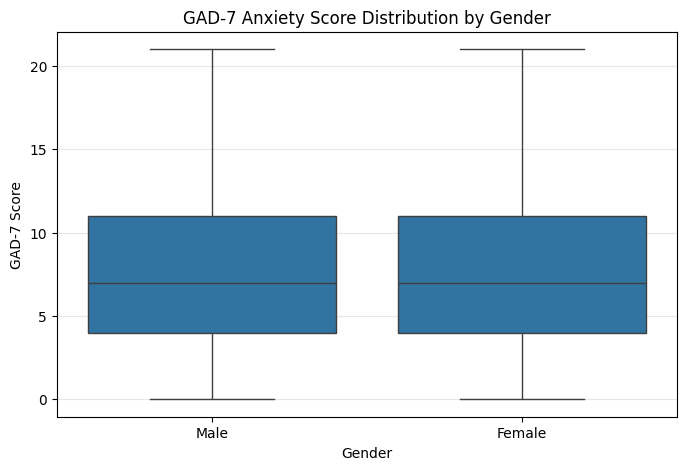

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_analysis, x="Gender", y="GAD_7_Score")
plt.title("GAD-7 Anxiety Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("GAD-7 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Violin Plot: GAD-7 Score by Gender

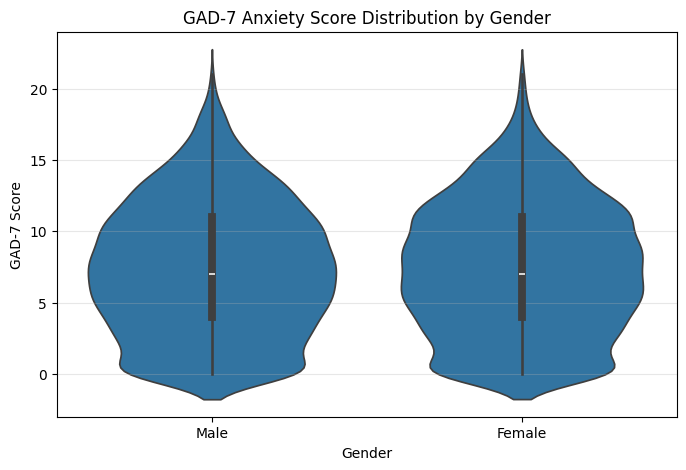

In [18]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_analysis, x="Gender", y="GAD_7_Score", inner="box")
plt.title("GAD-7 Anxiety Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("GAD-7 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Box Plot: PHQ-9 Score by Gender

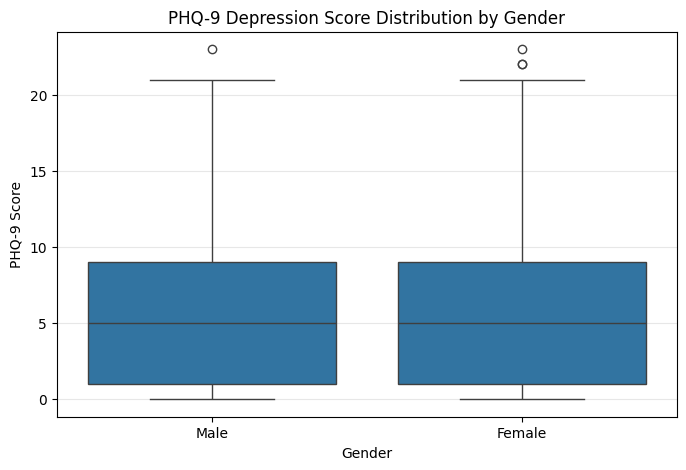

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_analysis, x="Gender", y="PHQ_9_Score")
plt.title("PHQ-9 Depression Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("PHQ-9 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Violin Plot: PHQ-9 Score by Gender

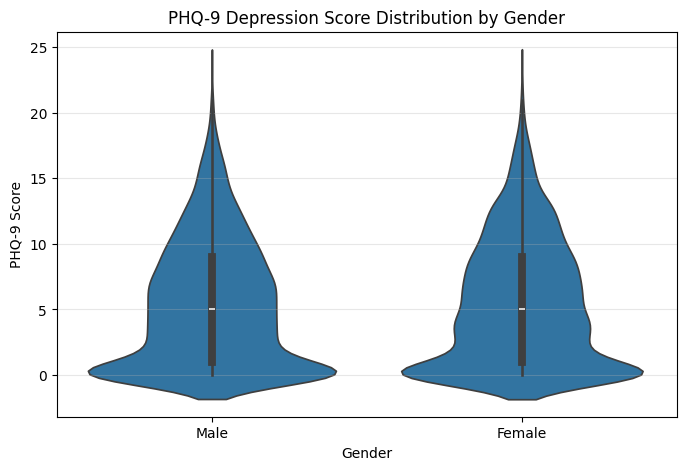

In [20]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_analysis, x="Gender", y="PHQ_9_Score", inner="box")
plt.title("PHQ-9 Depression Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("PHQ-9 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Box Plot: GAD-7 Score by Age

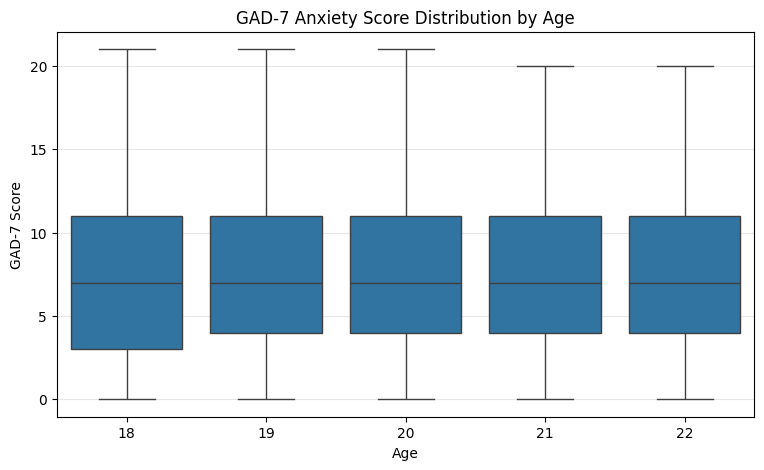

In [22]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_analysis, x="Age", y="GAD_7_Score")
plt.title("GAD-7 Anxiety Score Distribution by Age")
plt.xlabel("Age")
plt.ylabel("GAD-7 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Violin Plot: GAD-7 Score by Age

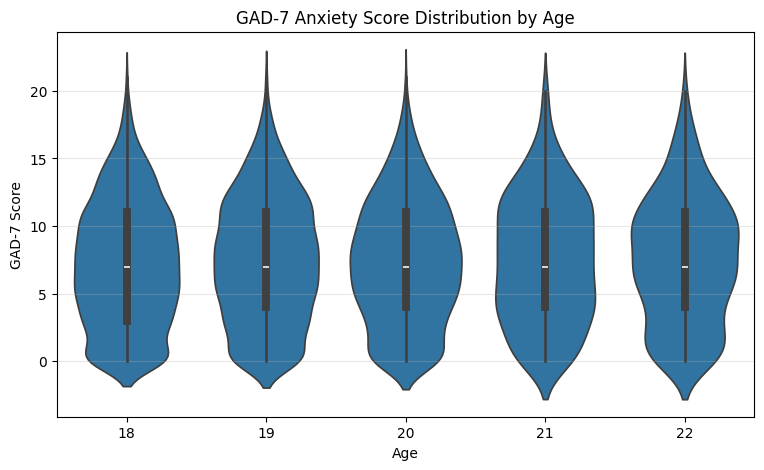

In [23]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df_analysis, x="Age", y="GAD_7_Score", inner="box")
plt.title("GAD-7 Anxiety Score Distribution by Age")
plt.xlabel("Age")
plt.ylabel("GAD-7 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Box Plot: PHQ-9 Score by Age

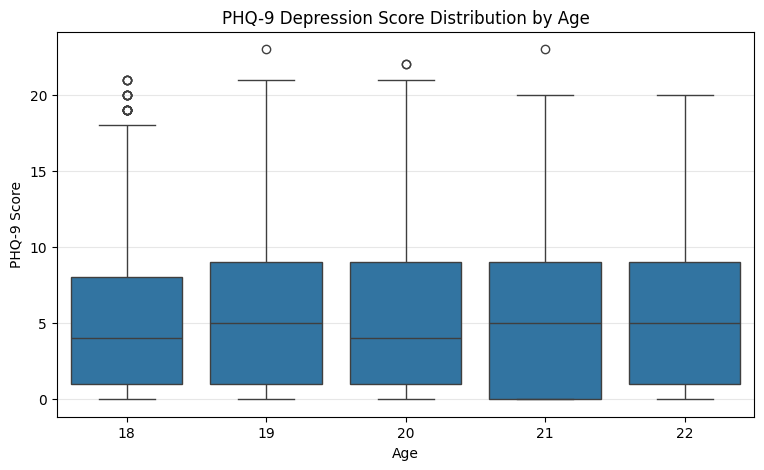

In [24]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_analysis, x="Age", y="PHQ_9_Score")
plt.title("PHQ-9 Depression Score Distribution by Age")
plt.xlabel("Age")
plt.ylabel("PHQ-9 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Violin Plot: PHQ-9 Score by Age

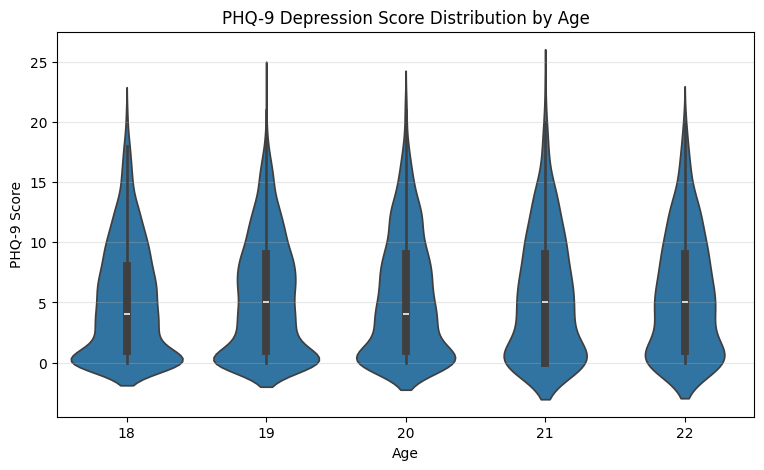

In [25]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df_analysis, x="Age", y="PHQ_9_Score", inner="box")
plt.title("PHQ-9 Depression Score Distribution by Age")
plt.xlabel("Age")
plt.ylabel("PHQ-9 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

#  Create age groups

In [26]:
# 16. Create age groups

def age_group(age):
    if age <= 19:
        return "18-19"
    elif age <= 21:
        return "20-21"
    else:
        return "22+"

df_analysis["Age_Group"] = df_analysis["Age"].apply(age_group)

display(df_analysis.head())

,Age,Gender,GAD_7_Score,PHQ_9_Score,Age_Group
0,18,Male,9,5,18-19
1,20,Male,0,8,20-21
2,18,Female,1,3,18-19
3,18,Female,13,0,18-19
4,18,Male,13,10,18-19


#  Box Plot: GAD-7 Score by Age Group

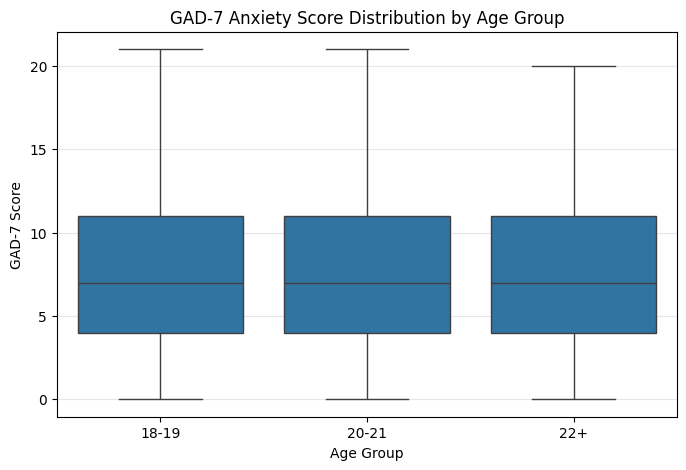

In [27]:
# 17. Box Plot: GAD-7 Score by Age Group

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_analysis, x="Age_Group", y="GAD_7_Score")
plt.title("GAD-7 Anxiety Score Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("GAD-7 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Violin Plot: GAD-7 Score by Age Group

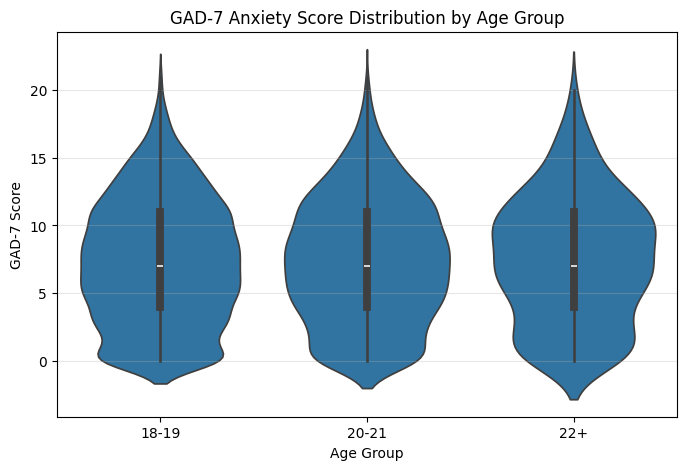

In [28]:
# 18. Violin Plot: GAD-7 Score by Age Group

plt.figure(figsize=(8, 5))
sns.violinplot(data=df_analysis, x="Age_Group", y="GAD_7_Score", inner="box")
plt.title("GAD-7 Anxiety Score Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("GAD-7 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Box Plot: PHQ-9 Score by Age Group

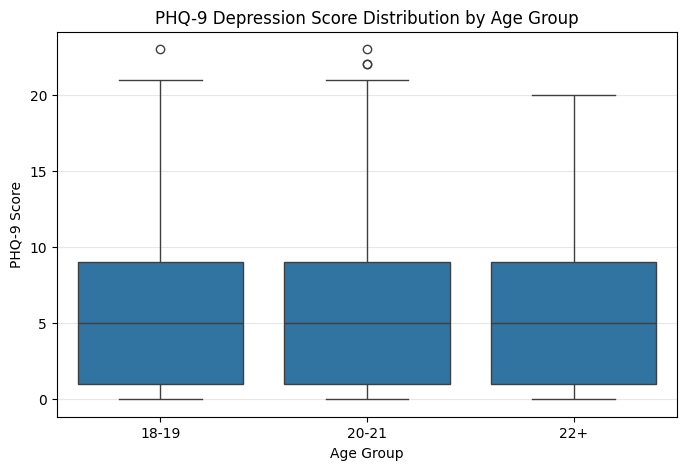

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_analysis, x="Age_Group", y="PHQ_9_Score")
plt.title("PHQ-9 Depression Score Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("PHQ-9 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Violin Plot: PHQ-9 Score by Age Group

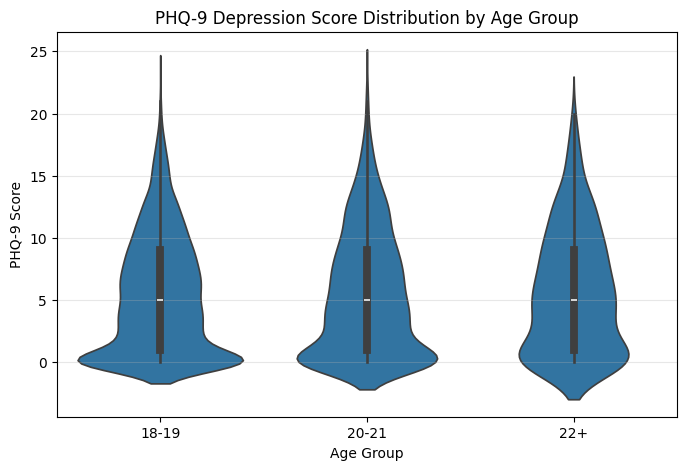

In [30]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_analysis, x="Age_Group", y="PHQ_9_Score", inner="box")
plt.title("PHQ-9 Depression Score Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("PHQ-9 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Combined Gender + Age Group Analysis

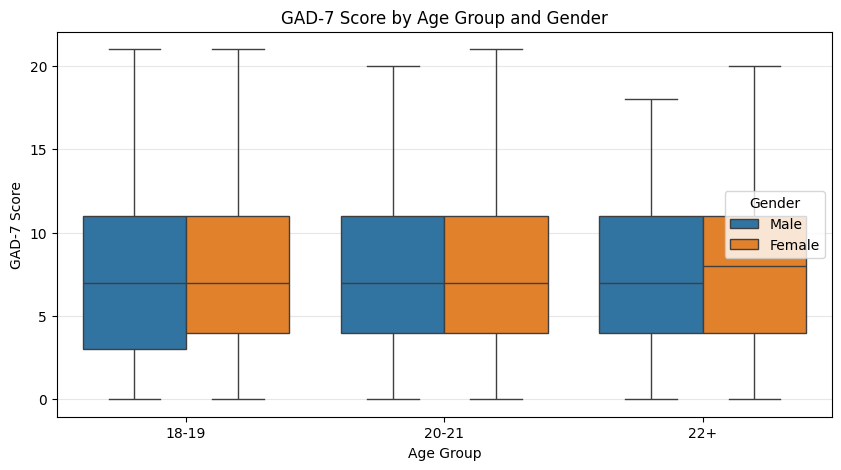

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_analysis, x="Age_Group", y="GAD_7_Score", hue="Gender")
plt.title("GAD-7 Score by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("GAD-7 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

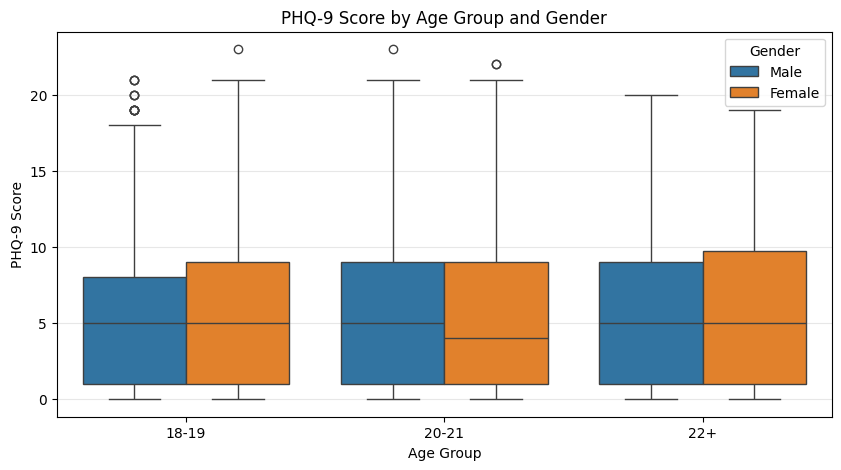

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_analysis, x="Age_Group", y="PHQ_9_Score", hue="Gender")
plt.title("PHQ-9 Score by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("PHQ-9 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Violin Plot: Gender + Age Group for GAD-7

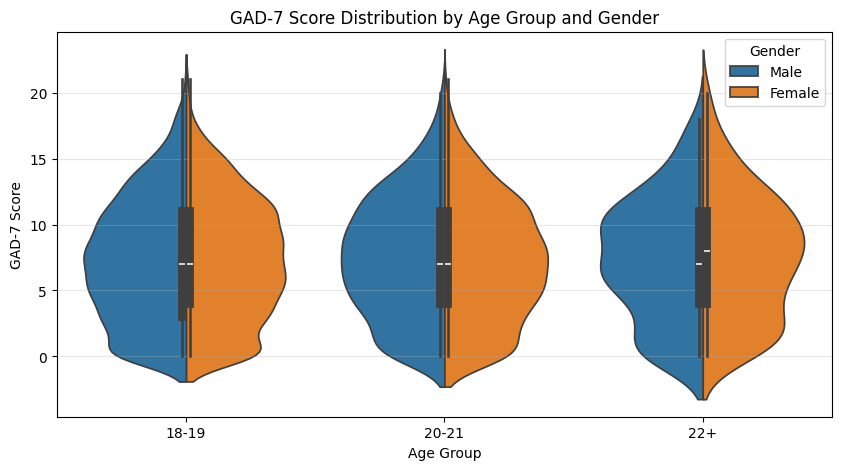

In [33]:
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df_analysis,
    x="Age_Group",
    y="GAD_7_Score",
    hue="Gender",
    split=True,
    inner="box"
)
plt.title("GAD-7 Score Distribution by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("GAD-7 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Violin Plot: Gender + Age Group for PHQ-9

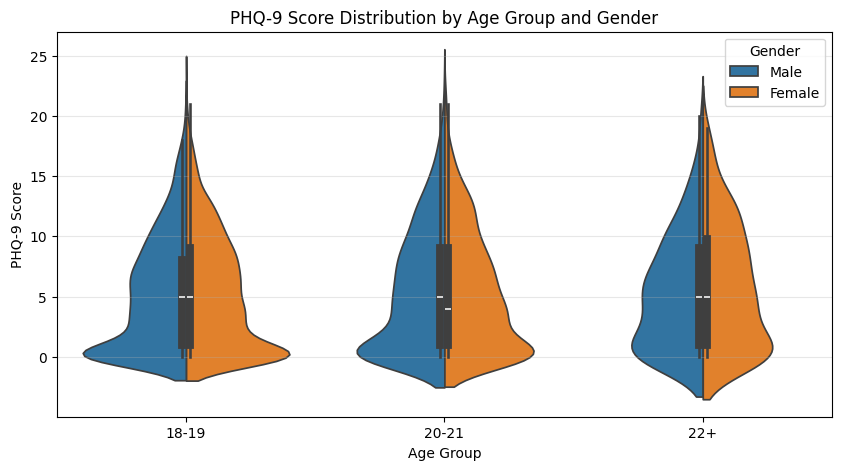

In [35]:
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df_analysis,
    x="Age_Group",
    y="PHQ_9_Score",
    hue="Gender",
    split=True,
    inner="box"
)
plt.title("PHQ-9 Score Distribution by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("PHQ-9 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Save summary table as CSV

In [36]:
summary_table = df_analysis.groupby(["Gender", "Age_Group"])[
    ["GAD_7_Score", "PHQ_9_Score"]
].agg(["count", "mean", "median", "std", "min", "max"])

summary_table.to_csv("score_distribution_summary.csv")

print("Summary CSV saved successfully.")
display(summary_table)

Summary CSV saved successfully.


GAD_7_Score                                    PHQ_9_Score  \
                       count      mean median       std min max       count   
Gender Age_Group                                                              
Female 18-19            2782  7.386053    7.0  4.632537   0  21        2782   
       20-21            1032  7.267442    7.0  4.587355   0  21        1032   
       22+               214  7.593458    8.0  4.748922   0  20         214   
Male   18-19            2799  7.272240    7.0  4.666143   0  21        2799   
       20-21             983  7.532045    7.0  4.567745   0  20         983   
       22+               190  7.378947    7.0  4.623792   0  18         190   

                                                     
                      mean median       std min max  
Gender Age_Group                                     
Female 18-19      5.381021    5.0  4.790322   0  23  
       20-21      5.446705    4.0  4.936362   0  22  
       22+        5.915888    5.0  5.125874   0  19  
Male   18-19      5.260807    5.0  4.714570   0  21  
       20-21      5.524924    5.0  5.001541   0  23  
       22+        5.410526    5.0  4.690404   0  20

# Final simple insight generation

In [37]:
gender_summary = df_analysis.groupby("Gender")[["GAD_7_Score", "PHQ_9_Score"]].mean()
age_summary = df_analysis.groupby("Age")[["GAD_7_Score", "PHQ_9_Score"]].mean()

print("Average Score by Gender:")
display(gender_summary)

print("Average Score by Age:")
display(age_summary)

print("\nHighest Average Anxiety Gender:")
print(gender_summary["GAD_7_Score"].idxmax())

print("\nHighest Average Depression Gender:")
print(gender_summary["PHQ_9_Score"].idxmax())

print("\nHighest Average Anxiety Age:")
print(age_summary["GAD_7_Score"].idxmax())

print("\nHighest Average Depression Age:")
print(age_summary["PHQ_9_Score"].idxmax())

Average Score by Gender:


,GAD_7_Score,PHQ_9_Score
Gender,,
Female,7.366683,5.426266
Male,7.341641,5.333333


Average Score by Age:


,GAD_7_Score,PHQ_9_Score
Age,,
18,7.215730,5.246999
19,7.477433,5.417391
20,7.367018,5.471172
21,7.514925,5.539801
22,7.492574,5.678218



Highest Average Anxiety Gender:
Female

Highest Average Depression Gender:
Female

Highest Average Anxiety Age:
21

Highest Average Depression Age:
22


# Histogram — GAD-7 Score Distribution

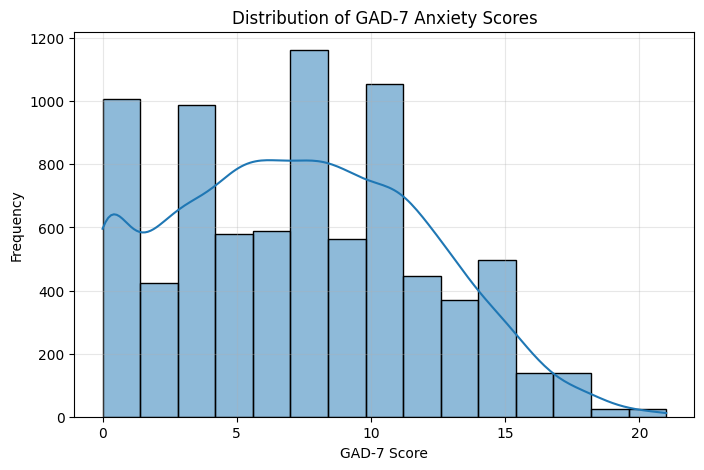

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_analysis["GAD_7_Score"],
    bins=15,
    kde=True
)

plt.title("Distribution of GAD-7 Anxiety Scores")
plt.xlabel("GAD-7 Score")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

# Histogram — PHQ-9 Score Distribution

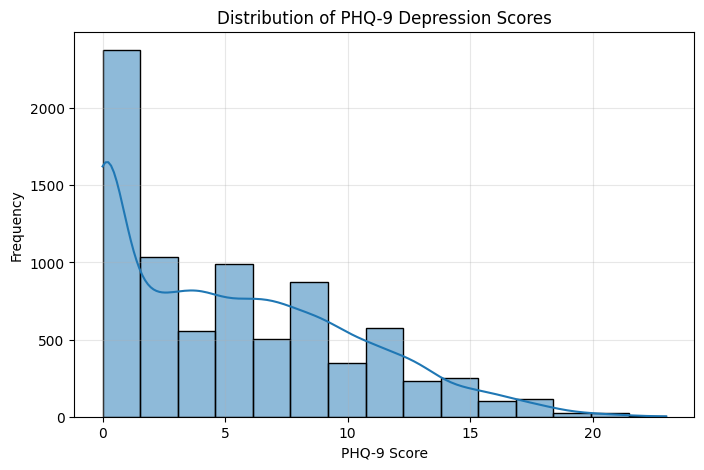

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_analysis["PHQ_9_Score"],
    bins=15,
    kde=True
)

plt.title("Distribution of PHQ-9 Depression Scores")
plt.xlabel("PHQ-9 Score")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

# Distribution by Gender — GAD-7

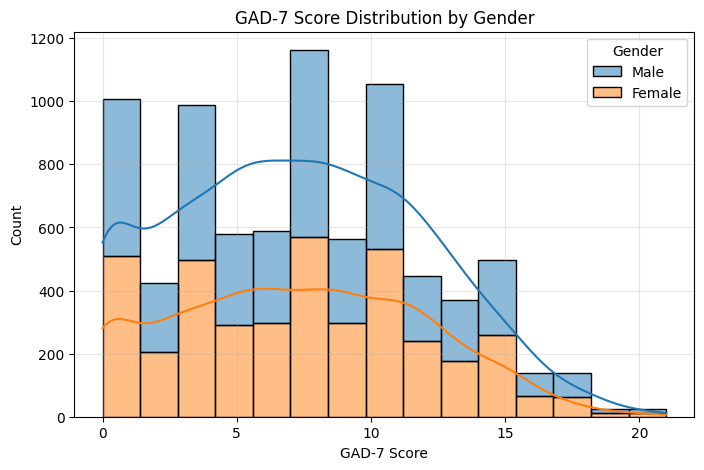

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_analysis,
    x="GAD_7_Score",
    hue="Gender",
    kde=True,
    bins=15,
    multiple="stack"
)

plt.title("GAD-7 Score Distribution by Gender")
plt.xlabel("GAD-7 Score")
plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

# Distribution by Gender — PHQ-9

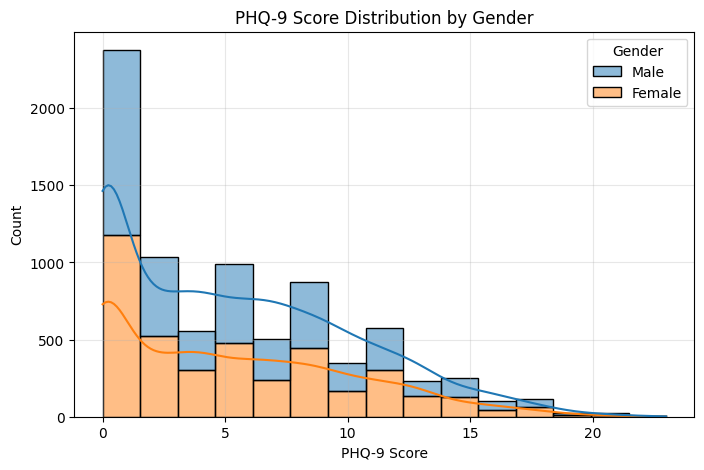

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_analysis,
    x="PHQ_9_Score",
    hue="Gender",
    kde=True,
    bins=15,
    multiple="stack"
)

plt.title("PHQ-9 Score Distribution by Gender")
plt.xlabel("PHQ-9 Score")
plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

# KDE Plot — Anxiety Score Density

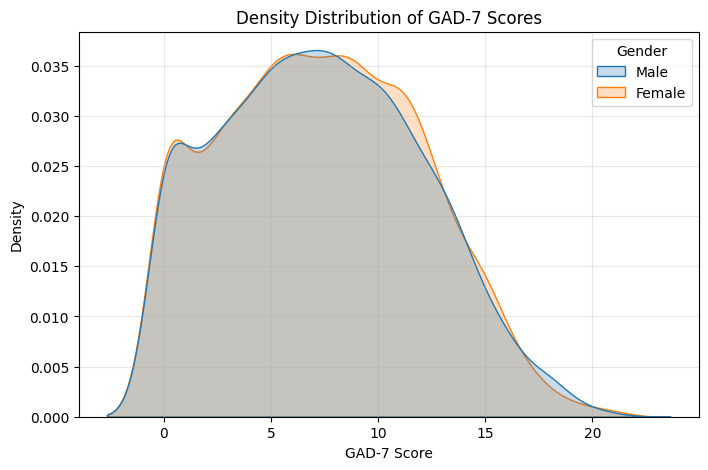

In [43]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_analysis,
    x="GAD_7_Score",
    hue="Gender",
    fill=True
)

plt.title("Density Distribution of GAD-7 Scores")
plt.xlabel("GAD-7 Score")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()

# KDE Plot — Depression Score Density

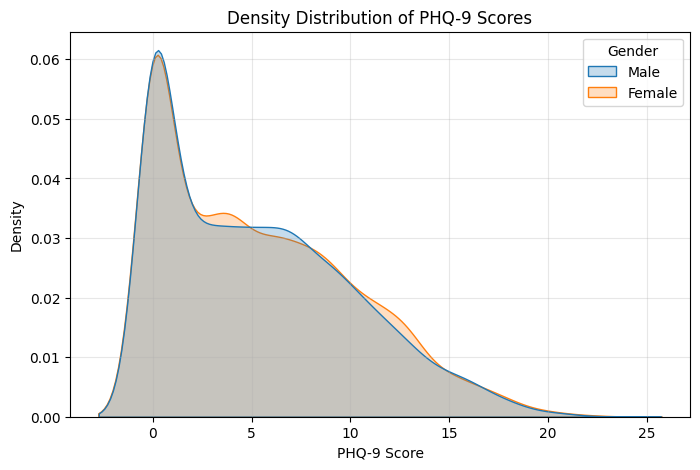

In [44]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_analysis,
    x="PHQ_9_Score",
    hue="Gender",
    fill=True
)

plt.title("Density Distribution of PHQ-9 Scores")
plt.xlabel("PHQ-9 Score")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()

# Age-wise Distribution — GAD-7

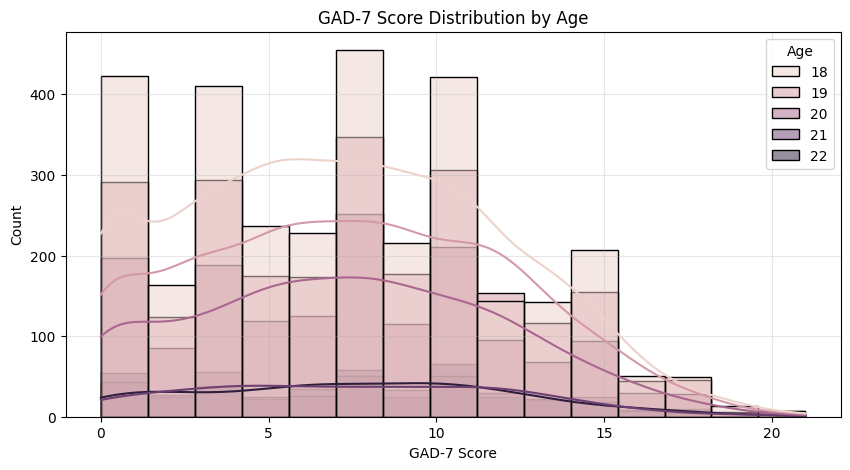

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_analysis,
    x="GAD_7_Score",
    hue="Age",
    kde=True,
    bins=15
)

plt.title("GAD-7 Score Distribution by Age")
plt.xlabel("GAD-7 Score")
plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

# Age-wise Distribution — PHQ-9

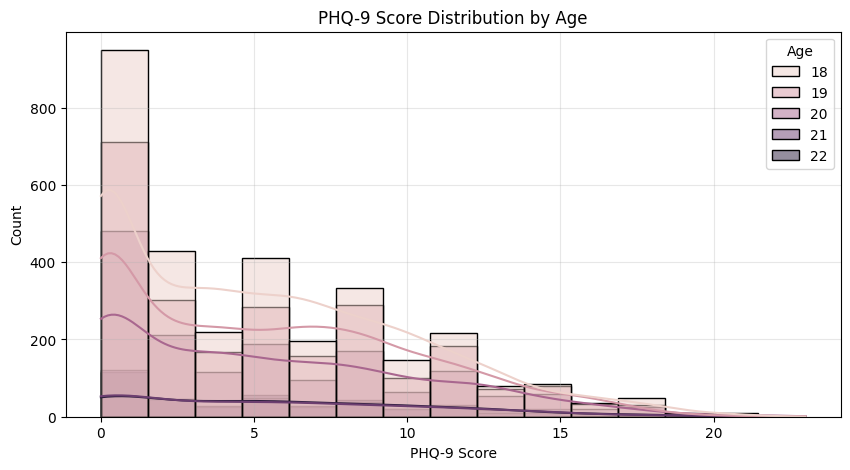

In [46]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_analysis,
    x="PHQ_9_Score",
    hue="Age",
    kde=True,
    bins=15
)

plt.title("PHQ-9 Score Distribution by Age")
plt.xlabel("PHQ-9 Score")
plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

# Combined Distribution Plot

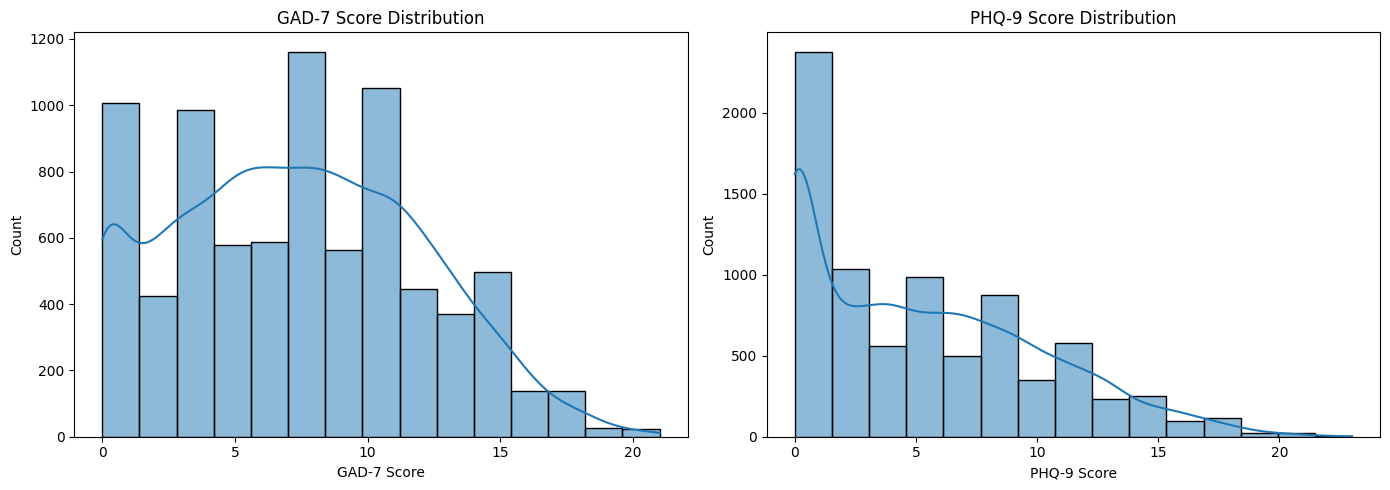

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# GAD-7
sns.histplot(
    df_analysis["GAD_7_Score"],
    kde=True,
    bins=15,
    ax=axes[0]
)

axes[0].set_title("GAD-7 Score Distribution")
axes[0].set_xlabel("GAD-7 Score")

# PHQ-9
sns.histplot(
    df_analysis["PHQ_9_Score"],
    kde=True,
    bins=15,
    ax=axes[1]
)

axes[1].set_title("PHQ-9 Score Distribution")
axes[1].set_xlabel("PHQ-9 Score")

plt.tight_layout()

plt.show()

# ECDF Distribution Plot 

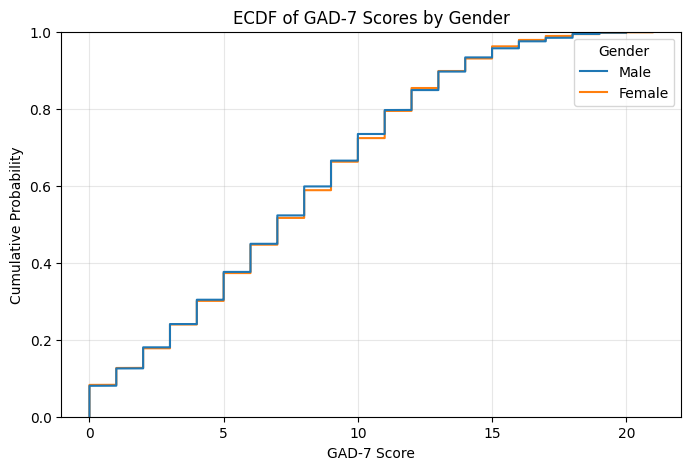

In [48]:
plt.figure(figsize=(8,5))

sns.ecdfplot(
    data=df_analysis,
    x="GAD_7_Score",
    hue="Gender"
)

plt.title("ECDF of GAD-7 Scores by Gender")
plt.xlabel("GAD-7 Score")
plt.ylabel("Cumulative Probability")

plt.grid(alpha=0.3)

plt.show()

# ECDF Plot — PHQ-9

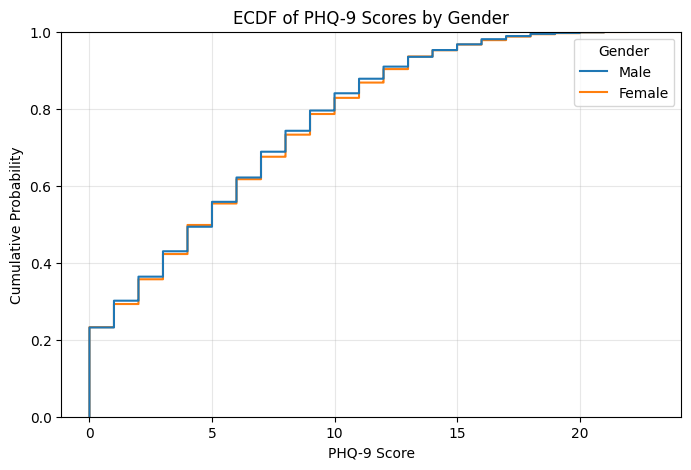

In [49]:
plt.figure(figsize=(8,5))

sns.ecdfplot(
    data=df_analysis,
    x="PHQ_9_Score",
    hue="Gender"
)

plt.title("ECDF of PHQ-9 Scores by Gender")
plt.xlabel("PHQ-9 Score")
plt.ylabel("Cumulative Probability")

plt.grid(alpha=0.3)

plt.show()